In [1]:
from scipy.linalg import expm
import matplotlib.pyplot as plt
import numpy as np

## Task A

Parameters

In [16]:
t0 = 5
tau = 1
time = np.linspace(0, 10, 1000000)
Omega = 5*np.pi

Plots

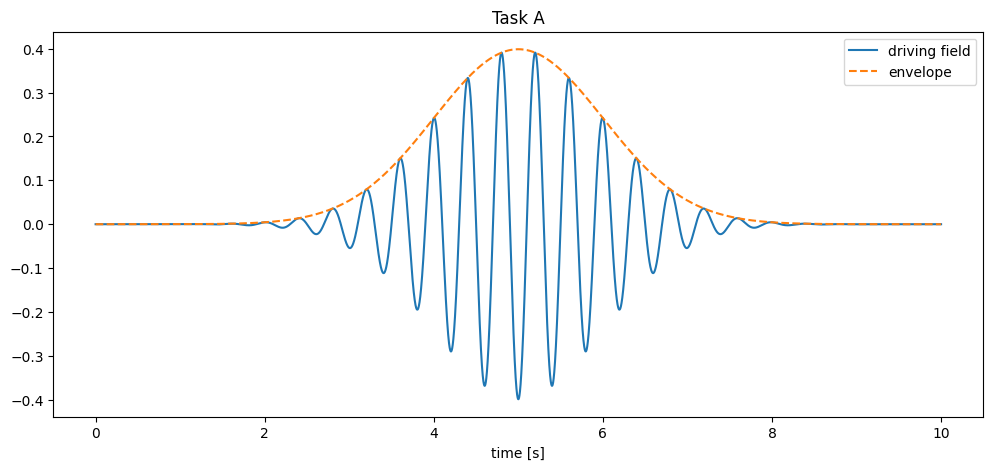

In [21]:
f_env = (1/ (tau* np.sqrt(2 * np.pi))) * np.exp(- (time - t0)**2 / (2 * tau**2))
f = f_env*np.cos(Omega*time) #impuls, driving field

plt.figure(figsize = (12,5))
plt.plot(time, f, label = 'driving field')
plt.plot(time, f_env, linestyle = 'dashed', label = 'envelope')
plt.title('Task A')
plt.xlabel('time [s]')
plt.legend()


## Task B

In [4]:
from scipy.linalg import expm

def evolution(t, omega, f, A):
    dt = t[1] - t[0]
    
    psi = np.array([1, 0], dtype=complex)
    psi_t = [psi]

    # Macierze Pauliego
    sz = np.array([[1, 0], [0, -1]], dtype=complex)
    sx = np.array([[0, 1], [1, 0]], dtype=complex)

    for i in range(len(t) - 1):
        H = (omega/ 2.0) * sz + A * f[i] * sx
        U = expm(-1j * H * dt)
        
        new_psi = U @ psi_t[i]
        psi_t.append(new_psi)

    return np.array(psi_t)

In [5]:
sz = np.array([[1,0], [0,-1]], dtype = complex)
sx = np.array([[0,1], [1,0]], dtype = complex)

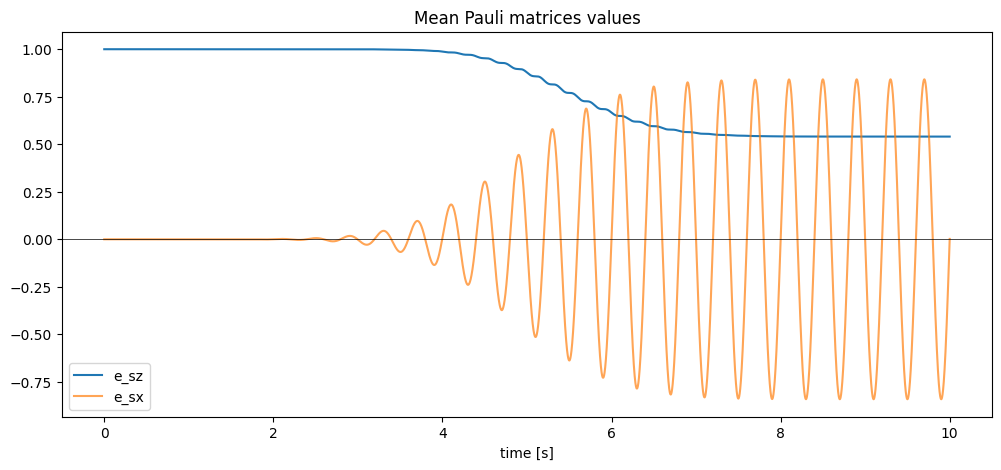

In [24]:
psi_t = evolution(time, Omega, f, A = 1)
e_sz = [np.real(np.vdot(p, sz @ p)) for p in psi_t]
e_sx = [np.real(np.vdot(p, sx @ p)) for p in psi_t]


plt.figure(figsize=(12, 5))
plt.plot(time, e_sz, label='e_sz')
plt.plot(time, e_sx, label='e_sx', alpha=0.7)
plt.axhline(0, color='black', lw=0.5)
plt.title('Mean Pauli matrices values')
plt.xlabel('time [s]')
plt.legend()
plt.show()

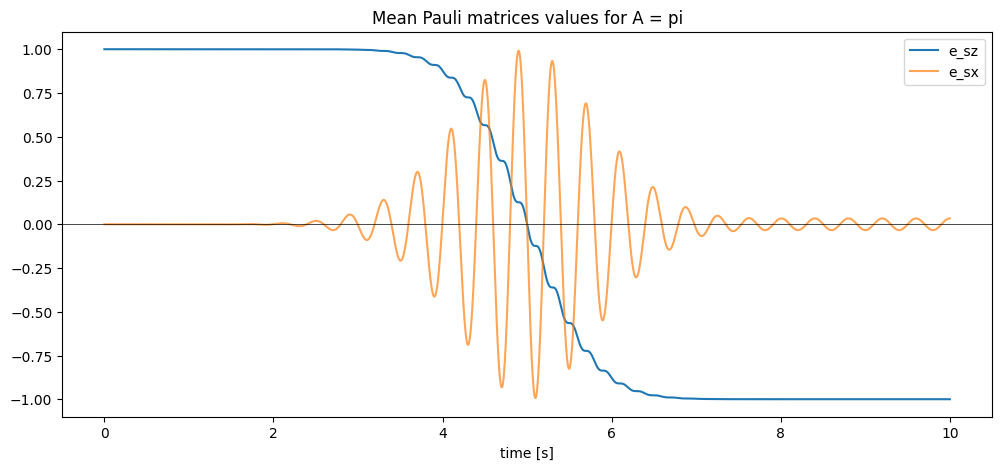

In [26]:
psi_t_pi = evolution(time, Omega, f, A = np.pi)

e_sz_pi = [np.real(np.vdot(p, sz @ p)) for p in psi_t_pi]
e_sx_pi = [np.real(np.vdot(p, sx @ p)) for p in psi_t_pi]

plt.figure(figsize=(12, 5))
plt.plot(time, e_sz_pi, label='e_sz')
plt.plot(time, e_sx_pi, label='e_sx', alpha=0.7)
plt.axhline(0, color='black', lw=0.5)
plt.title('Mean Pauli matrices values for A = pi')
plt.xlabel('time [s]')
plt.legend()
plt.show()

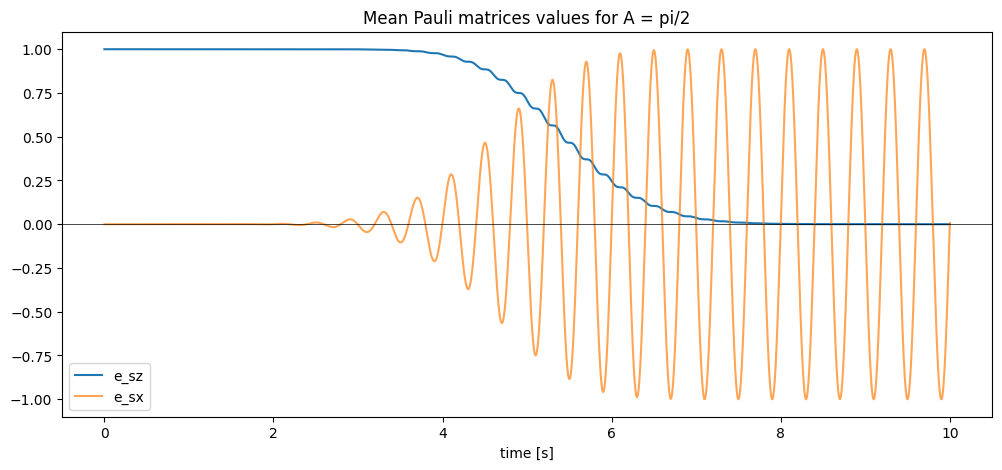

In [28]:
psi_t_pi_2 = evolution(time, Omega, f, A = np.pi/2)

e_sz_pi_2 = [np.real(np.vdot(p, sz @ p)) for p in psi_t_pi_2]
e_sx_pi_2 = [np.real(np.vdot(p, sx @ p)) for p in psi_t_pi_2]

plt.figure(figsize=(12, 5))
plt.plot(time, e_sz_pi_2, label='e_sz')
plt.plot(time, e_sx_pi_2, label='e_sx', alpha=0.7)
plt.axhline(0, color='black', lw=0.5)
plt.title('Mean Pauli matrices values for A = pi/2')
plt.xlabel('time [s]')
plt.legend()
plt.show()

## Task C

In [9]:
from scipy.integrate import cumulative_trapezoid

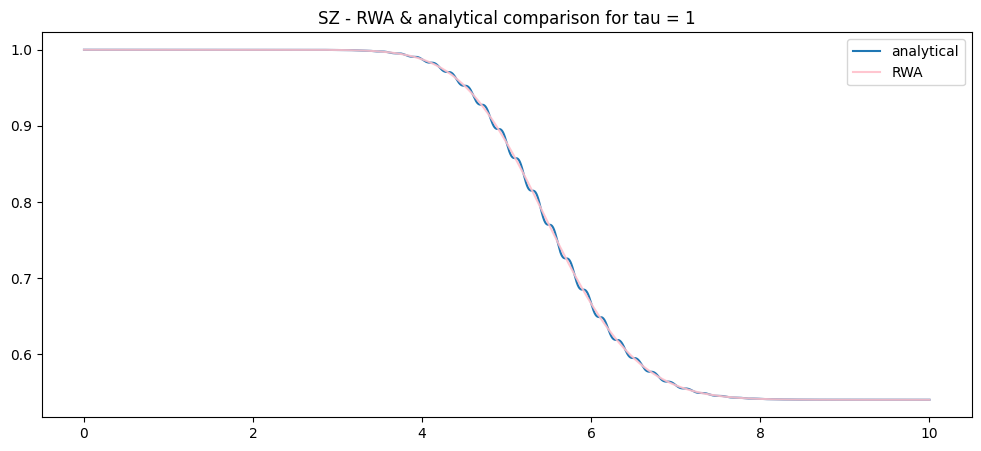

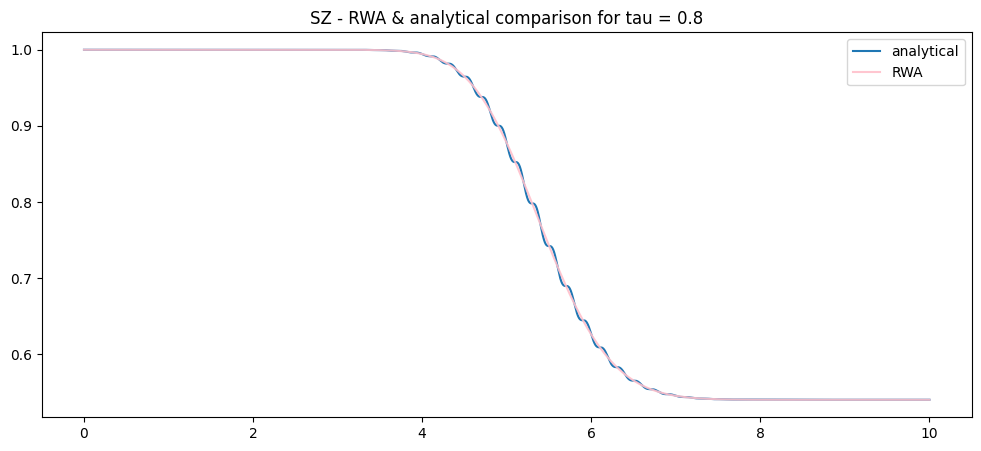

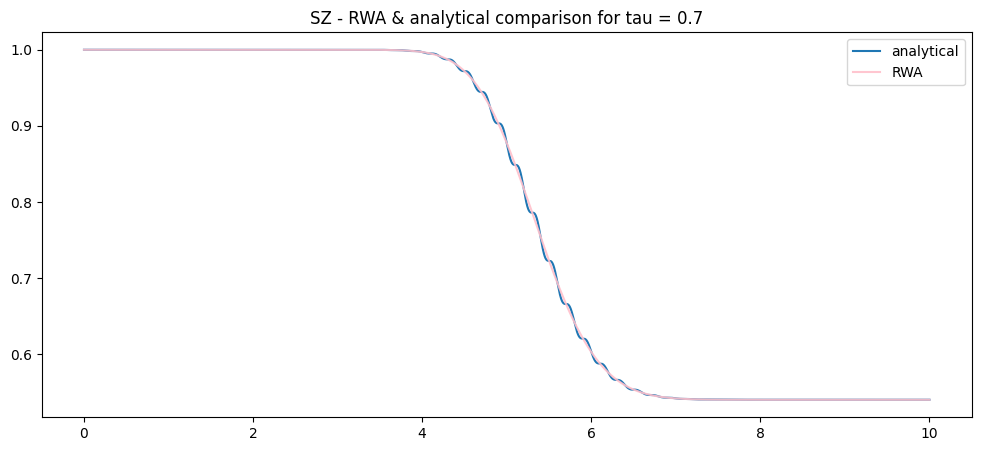

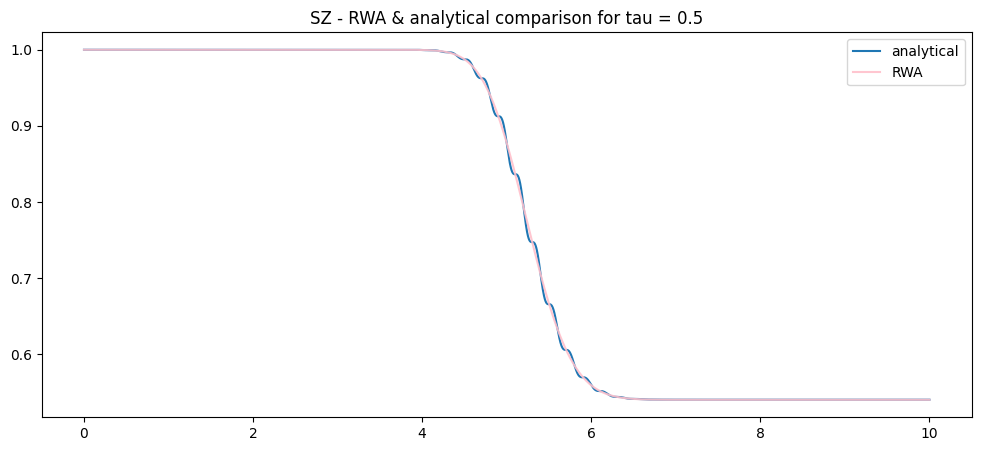

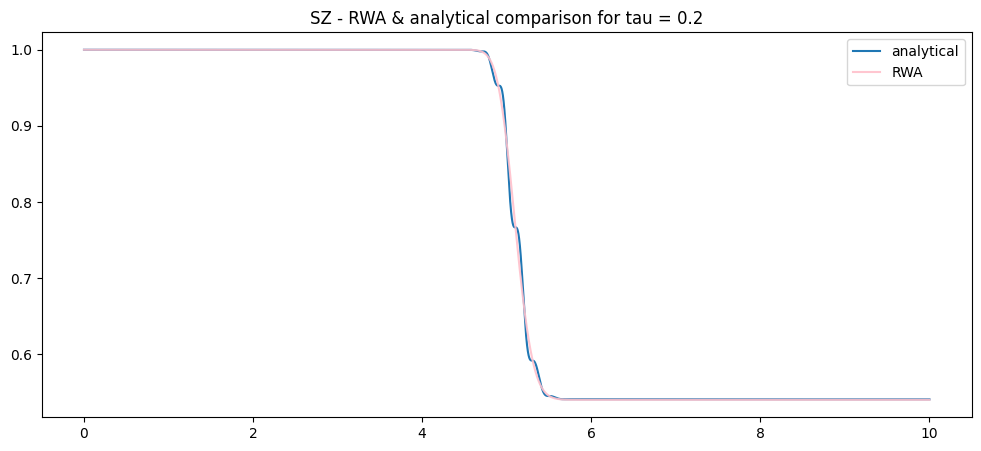

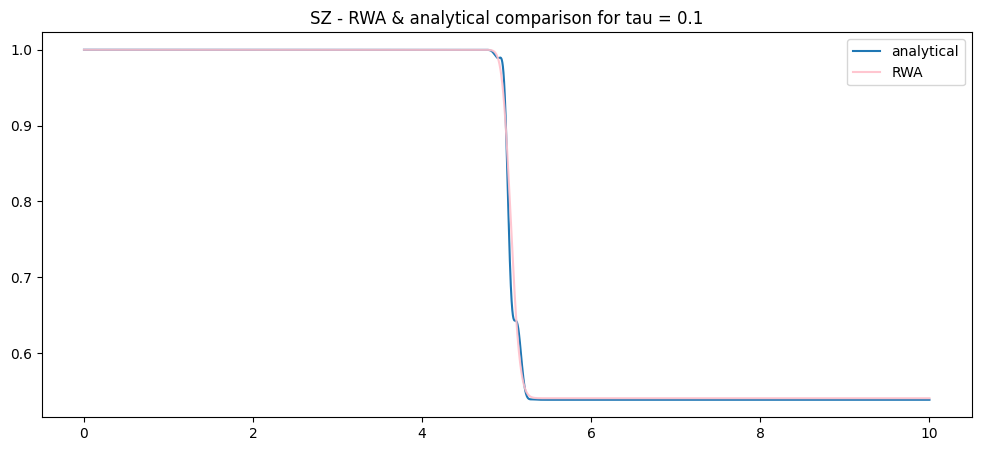

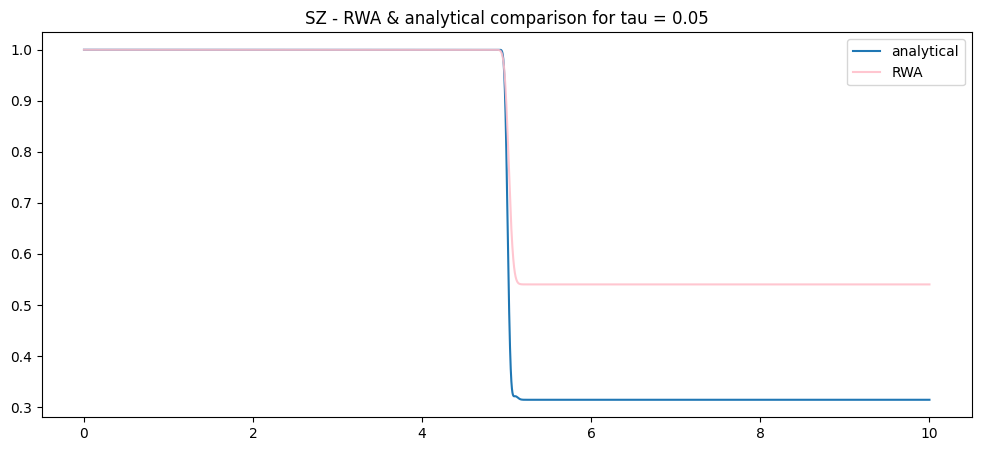

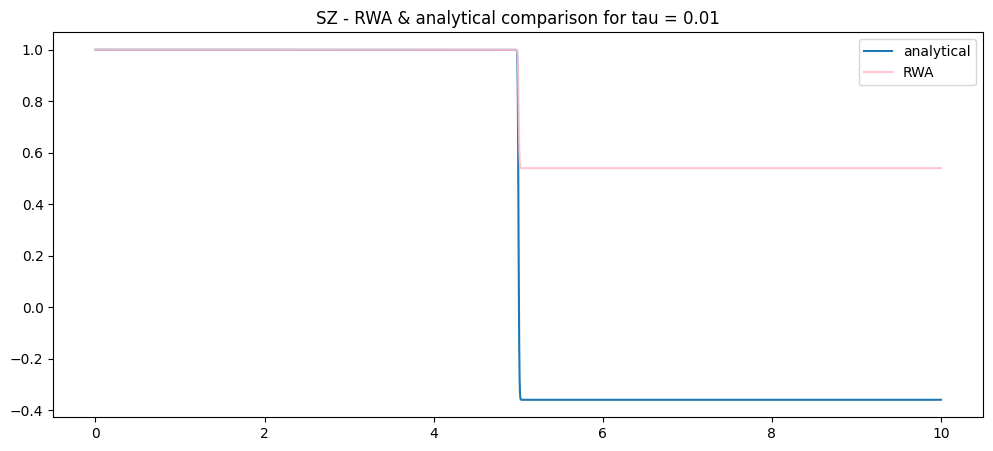

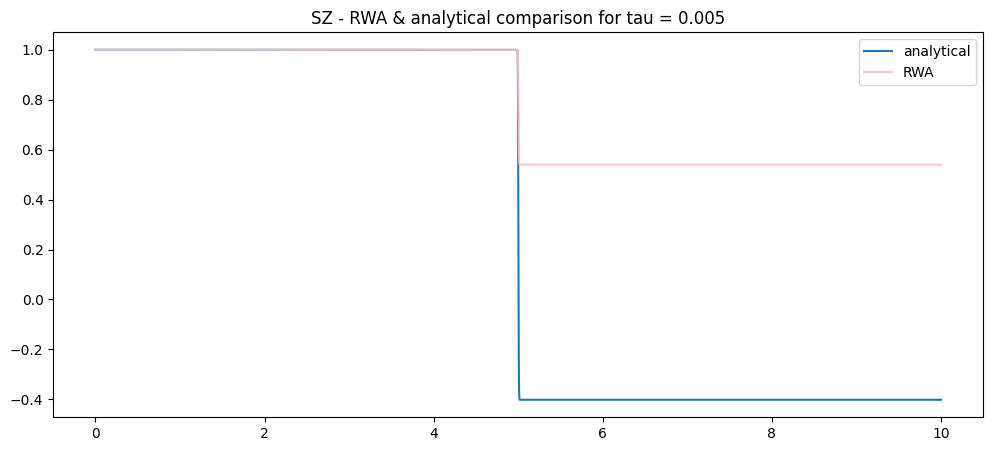

In [29]:
def waves(tau, t0 = 5, time = np.linspace(0, 10, 1000000), Omega = 5*np.pi):
    f_env = (1/ (tau* np.sqrt(2 * np.pi))) * np.exp(- (time - t0)**2 / (2 * tau**2))
    f = f_env*np.cos(Omega*time)
    return f_env, f

for tau in [1, 0.8, 0.7, 0.5, 0.2, 0.1, 0.05, 0.01, 0.005]:

    f_env, f = waves(tau)

    plt.figure(figsize = (12,5))
    I = cumulative_trapezoid(y=f_env, x=time, initial=0)
    RWA = np.cos(I)
    psi_t = evolution(time, Omega, f, A = 1)
    e_sz = [np.real(np.vdot(p, sz @ p)) for p in psi_t]
    
    plt.plot(time, e_sz, label = 'analytical')
    plt.plot(time, RWA, label = 'RWA', color = 'pink', alpha = 0.9) #smoother
    plt.title(f'SZ - RWA & analytical comparison for tau = {tau}')
    plt.legend()

There is a visible deviate of numerical solution from RWA for a very short pulse of tau = 0.05 or less